In [1]:
import numpy as np
from granuscore.loader import JSONLineReader
from evaluation.qa_datasets.eval_datasets import DATASETS
from evaluation.config import PROJECT_DIR
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

base_dir = f'{PROJECT_DIR}/data/qa_datasets'
models = ["deepseek-v3-2", "qwen3-32b", "qwen3-8b", "qwen3-8b-think", "olmo3-7b", "qwen3-06b"]

dataset_names = DATASETS.keys()

scores = defaultdict(dict)

# first pass: load everything
for model in models:
    for dataset_name in dataset_names:
        grades = JSONLineReader().read(f'{base_dir}/{dataset_name}/{model}/graded-{model}-{dataset_name}.jsonl')
        gold_output = DATASETS.get(dataset_name)
        gold_output_data = gold_output['data']
        if gold_output['mode'] == 'single':
            gold_output_lengths = [{'id': d['id'],
                                    'gold_output_len': len(d['answer'].split()),
                                    'question_len': len(d['question'].split())
                                    } for d in gold_output_data]
        else:
            gold_output_lengths = [
                {
                    'id': d['id'],
                    'gold_output_len': np.mean([len(a.split()) for a in d['answer']]),
                    'question_len': len(d['question'].split())
                }
                for d in gold_output_data
            ]
        output_granularities = JSONLineReader().read(
            f'{base_dir}/{dataset_name}/{model}/{model}-{dataset_name}-output-granularities.jsonl')
        gold_granularities = JSONLineReader().read(f'{base_dir}/{dataset_name}/granuscore-{dataset_name}.jsonl')

        df = (
            pd.DataFrame(grades)
            .merge(pd.DataFrame(gold_output_lengths), on="id", how="inner")
            .merge(pd.DataFrame(output_granularities), on="id", how="inner", suffixes=("", "_output"))
            .merge(pd.DataFrame(gold_granularities), on="id", how="inner", suffixes=("", "_gold"))
            .set_index("id")
        )

        df = df.dropna(subset=["answer_granularity", "answer_granularity_gold"])
        df["granularity_gap"] = df["answer_granularity"] - df["answer_granularity_gold"]

        scores[model][dataset_name] = df


# second pass: enforce inner join across models per dataset
for dataset_name in dataset_names:
    common_ids = set.intersection(
        *[set(scores[model][dataset_name].index) for model in models]
    )

    for model in models:
        scores[model][dataset_name] = scores[model][dataset_name].loc[list(common_ids)]

In [2]:
dataset_model_stat = defaultdict(dict)
for model in models:
    for dataset, stats in scores[model].items():
        dataset_model_stat[dataset][model] = stats.mean().to_dict()

In [3]:
for dataset, model_stats in dataset_model_stat.items():
    acc = 0
    count = 0
    for model, stats in dataset_model_stat[dataset].items():
        count += 1
        acc += stats['score']
    print(dataset, acc/count)

simple_qa 0.07799671592775041
facts_parametric 0.04988878296790594
squad 0.3024106002554278
truthful_qa 0.4346650020807324


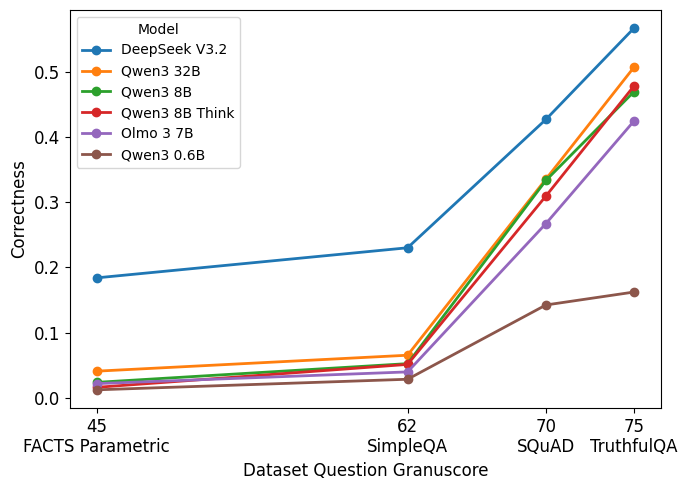

In [5]:
granularity_key = 'question_granularity'

NAME_LOOKUP = {
    'truthful_qa': 'TruthfulQA',
    'squad': 'SQuAD',
    'facts_parametric': 'FACTS Parametric',
    'simple_qa': 'SimpleQA',
}

MODEL_LOOKUP = {
    'deepseek-v3-2': 'DeepSeek V3.2',
    'olmo3-7b': 'Olmo 3 7B',
    'qwen3-06b': 'Qwen3 0.6B',
    'qwen3-8b': 'Qwen3 8B',
    'qwen3-8b-think': 'Qwen3 8B Think',
    'qwen3-32b': 'Qwen3 32B',
}

models = ["deepseek-v3-2", "qwen3-32b", "qwen3-8b", "qwen3-8b-think", "olmo3-7b", "qwen3-06b"]


rows = []
for dataset in dataset_model_stat:
    for model in models:
        df_ = dataset_model_stat[dataset][model]
        rows.append({
            "dataset": dataset,
            "model": MODEL_LOOKUP.get(model, model),
            "score": df_["score"],
            "granularity": df_[granularity_key],
        })

df = pd.DataFrame(rows)

# dataset order by granularity
dataset_info = (
    df[["dataset","granularity"]]
    .drop_duplicates()
    .sort_values("granularity")
)

datasets = dataset_info["dataset"].tolist()
granularities = dataset_info["granularity"].tolist()

fig, ax = plt.subplots(figsize=(7,5))

for model in models:
    label = MODEL_LOOKUP.get(model, model)

    g = df[df["model"] == label].set_index("dataset").loc[datasets]

    ax.plot(
        g["granularity"],
        g["score"],
        marker="o",
        linewidth=2,
        label=label
    )

# x-axis ticks = granularity + dataset names
ax.set_xticks(granularities)

ax.set_xticklabels(
    [
        f"{round(g)}\n{NAME_LOOKUP.get(d,d)}" if d != "simple_qa" or granularity_key != "answer_granularity_gold"
        else f"{round(g)}\n\n{NAME_LOOKUP.get(d,d)}"
        for d, g in zip(datasets, granularities)
    ]
)

x_label = "Dataset Gold Answer Granuscore" if granularity_key == "answer_granularity_gold" else "Dataset Question Granuscore"
ax.set_xlabel(x_label, fontsize=12)
ax.set_ylabel("Correctness", fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)


ax.legend(title="Model", loc="upper left")

plt.tight_layout()
fig.savefig(f"{PROJECT_DIR}/data/qa_datasets/qa_scatter_{granularity_key}.pdf", bbox_inches="tight")
plt.show()

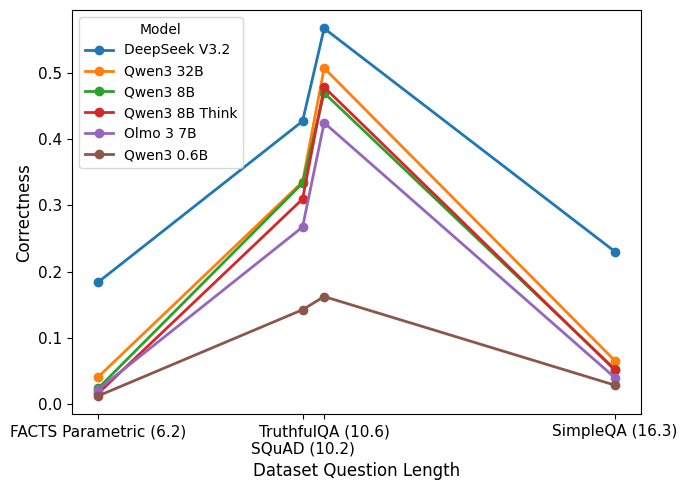

In [196]:
NAME_LOOKUP = {
    'truthful_qa': 'TruthfulQA',
    'squad': 'SQuAD',
    'facts_parametric': 'FACTS Parametric',
    'simple_qa': 'SimpleQA',
}

MODEL_LOOKUP = {
    'deepseek-v3-2': 'DeepSeek V3.2',
    'olmo3-7b': 'Olmo 3 7B',
    'qwen3-06b': 'Qwen3 0.6B',
    'qwen3-8b': 'Qwen3 8B',
    'qwen3-8b-think': 'Qwen3 8B Think',
    'qwen3-32b': 'Qwen3 32B',
}

models = ["deepseek-v3-2", "qwen3-32b", "qwen3-8b", "qwen3-8b-think", "olmo3-7b", "qwen3-06b"]

granularity_key = 'question_len'


rows = []
for dataset in dataset_model_stat:
    for model in models:
        df_ = dataset_model_stat[dataset][model]
        rows.append({
            "dataset": dataset,
            "model": MODEL_LOOKUP.get(model, model),
            "score": df_["score"],
            "granularity": df_[granularity_key]
        })

df = pd.DataFrame(rows)

# dataset order by granularity
dataset_info = (
    df[["dataset","granularity"]]
    .drop_duplicates()
    .sort_values("granularity")
)

datasets = dataset_info["dataset"].tolist()
granularities = dataset_info["granularity"].tolist()

fig, ax = plt.subplots(figsize=(7,5))

for model in models:
    label = MODEL_LOOKUP.get(model, model)

    g = df[df["model"] == label].set_index("dataset").loc[datasets]

    ax.plot(
        g["granularity"],
        g["score"],
        marker="o",
        linewidth=2,
        label=label
    )

# x-axis ticks = granularity + dataset names
ax.set_xticks(granularities)


CUSTOM_LABELS = {
    "facts_parametric": "{d} ({g})",
    "simple_qa": "\n\n{d} ({g})" if granularity_key == "answer_granularity_gold" else "{d} ({g})",   # extra spacing
    "squad": "\n{d} ({g})",
    "truthful_qa": "{d} ({g})",
}

ax.set_xticklabels(
    [
        CUSTOM_LABELS.get(d, "{g}\n{d}").format(
            g=round(g, 1),
            d=NAME_LOOKUP.get(d, d)
        )
        for d, g in zip(datasets, granularities)
    ]
)

if granularity_key == "answer_granularity_gold":
    x_label = "Dataset Gold Answer Length"
else:
    x_label = "Dataset Question Length"
ax.set_xlabel(x_label, fontsize=12)
ax.set_ylabel("Correctness", fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=11)

ax.legend(title="Model", loc="upper left")

plt.tight_layout()
fig.savefig(f"{PROJECT_DIR}/data/qa_datasets/qa_scatter_{granularity_key}.pdf", bbox_inches="tight")
plt.show()

In [6]:
import pandas as pd
import numpy as np

model_stats = {}

metrics = [
    "answer_granularity",
    "answer_granularity_gold",
    "question_granularity",
    "granularity_gap",
    "reasoning_granularity",
]

# --- compute per-model statistics ---
for model in models:
    stats_all = pd.concat(
        [
            df.assign(dataset=dataset)
            for dataset, df in scores[model].items()
        ],
        ignore_index=True
    )

    stats_all["label"] = np.select(
        [
            stats_all["is_correct"] == 1,
            stats_all["is_incorrect"] == 1,
            stats_all["is_not_attempted"] == 1,
        ],
        [
            "correct",
            "incorrect",
            "not_attempted",
        ],
        default="unknown",
    )

    means = (
        stats_all
        .groupby("label")[metrics]
        .mean()
    )

    model_stats[model] = means


# --- combine all models ---
all_models = pd.concat(model_stats, names=["model", "label"])


# --- compute mean and std across models ---
mean_stats = all_models.groupby("label").mean()
std_stats = all_models.groupby("label").std()


# --- format as mean ± std ---
table = (
    mean_stats.map(lambda x: f"{x:.1f}")
    + "(" + std_stats.map(lambda x: f"{x:.1f}") + ")"
)

# transpose to match paper layout
table = table.T

# ensure column order
table = table[["correct", "incorrect", "not_attempted"]]


# --- export latex ---
latex = table.to_latex(
    caption="Mean granularity statistics per label (mean ± std across models).",
    label="tab:granularity_label_means",
    escape=False
)

print(latex)

\begin{table}
\caption{Mean granularity statistics per label (mean ± std across models).}
\label{tab:granularity_label_means}
\begin{tabular}{llll}
\toprule
label & correct & incorrect & not_attempted \\
\midrule
answer_granularity & 69.6(1.7) & 66.0(1.4) & 72.5(1.3) \\
answer_granularity_gold & 59.4(4.1) & 45.8(0.7) & 48.7(2.7) \\
question_granularity & 70.1(1.5) & 65.4(0.3) & 67.2(0.6) \\
granularity_gap & 10.1(2.4) & 20.2(1.9) & 23.8(1.7) \\
reasoning_granularity & 68.2(nan) & 66.0(nan) & 70.0(nan) \\
\bottomrule
\end{tabular}
\end{table}



/var/folders/pf/gbn3rrqn3sn7212qgqt0n3rw0000gn/T/ipykernel_99479/807519477.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_models = pd.concat(model_stats, names=["model", "label"])


### Dataset Characteristics

In [7]:
from itertools import combinations
from scipy.stats import mannwhitneyu

def calculate_mannwhitneyu(data, key):
    pairs = list(combinations(data.keys(), 2))
    results = []

    for a, b in pairs:
        stat, p = mannwhitneyu(
            data[a][key],
            data[b][key],
            alternative="two-sided"
        )
        results.append((a, b, p))

    # Bonferroni correction
    m = len(results)
    results = [(a, b, min(p * m, 1.0)) for a, b, p in results]

    for a, b, p in results:
        print(f"{a} vs {b}: p={p:.4g}")

    return results

print('gold answer')
calculate_mannwhitneyu(scores['qwen3-8b'], "answer_granularity_gold")

gold answer
simple_qa vs facts_parametric: p=0.001054
simple_qa vs squad: p=0
simple_qa vs truthful_qa: p=2.569e-285
facts_parametric vs squad: p=6.732e-153
facts_parametric vs truthful_qa: p=7.893e-202
squad vs truthful_qa: p=1.032e-56


[('simple_qa', 'facts_parametric', np.float64(0.0010541235505759593)),
 ('simple_qa', 'squad', np.float64(0.0)),
 ('simple_qa', 'truthful_qa', np.float64(2.5692820666496536e-285)),
 ('facts_parametric', 'squad', np.float64(6.732039701570324e-153)),
 ('facts_parametric', 'truthful_qa', np.float64(7.893010866558299e-202)),
 ('squad', 'truthful_qa', np.float64(1.0319139872109533e-56))]

In [8]:
from itertools import combinations

print('question')
calculate_mannwhitneyu(scores['qwen3-8b'], "question_granularity")

question
simple_qa vs facts_parametric: p=1.93e-181
simple_qa vs squad: p=0
simple_qa vs truthful_qa: p=2.001e-180
facts_parametric vs squad: p=0
facts_parametric vs truthful_qa: p=3.091e-217
squad vs truthful_qa: p=3.175e-30


[('simple_qa', 'facts_parametric', np.float64(1.9303820057962375e-181)),
 ('simple_qa', 'squad', np.float64(0.0)),
 ('simple_qa', 'truthful_qa', np.float64(2.00052788459644e-180)),
 ('facts_parametric', 'squad', np.float64(0.0)),
 ('facts_parametric', 'truthful_qa', np.float64(3.090980319662212e-217)),
 ('squad', 'truthful_qa', np.float64(3.1747933457531184e-30))]

### Response Outcomes

In [9]:
all_all = []

for model in models:
    stats_all = pd.concat(
        [
            df.assign(dataset=dataset)
            for dataset, df in scores[model].items()
        ],
        ignore_index=True
    )

    stats_all["label"] = np.select(
        [
            stats_all["is_correct"] == 1,
            stats_all["is_incorrect"] == 1,
            stats_all["is_not_attempted"] == 1,
        ],
        [
            "correct",
            "incorrect",
            "not_attempted",
        ],
        default="unknown",
    )
    all_all.append(stats_all)
all_all_df = pd.concat(all_all, ignore_index=True)

/var/folders/pf/gbn3rrqn3sn7212qgqt0n3rw0000gn/T/ipykernel_99479/715719746.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_all_df = pd.concat(all_all, ignore_index=True)


In [10]:
from sklearn.model_selection import StratifiedKFold
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm

all_all_df["failure"] = (all_all_df.label != "correct").astype(int)
X = sm.add_constant(all_all_df[["granularity_gap"]])
y = all_all_df["failure"]
model = sm.Logit(y, X).fit(disp=False)
print(model.summary())

odds_ratio = np.exp(model.params["granularity_gap"])
print("Odds ratio (granularity_gap):", odds_ratio)

probs = model.predict(X)

auc = roc_auc_score(y, probs)
print("AUC (gap only):", auc)

X = all_all_df[["granularity_gap"]].values
y = all_all_df["failure"].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []

for train, test in cv.split(X, y):
    model = sm.Logit(y[train], sm.add_constant(X[train])).fit(disp=False)
    probs = model.predict(sm.add_constant(X[test]))
    aucs.append(roc_auc_score(y[test], probs))

print(np.mean(aucs), np.std(aucs))

                           Logit Regression Results                           
Dep. Variable:                failure   No. Observations:                99318
Model:                          Logit   Df Residuals:                    99316
Method:                           MLE   Df Model:                            1
Date:                Sun, 15 Mar 2026   Pseudo R-squ.:                 0.02862
Time:                        18:37:51   Log-Likelihood:                -52605.
converged:                       True   LL-Null:                       -54154.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.8898      0.009    100.660      0.000       0.873       0.907
granularity_gap     0.0187      0.000     54.144      0.000       0.018       0.019
Odds ratio (granularity_gap): 1.

In [11]:
for stat in ['answer_granularity', 'answer_granularity_gold', 'question_granularity', 'granularity_gap']:
    stat_answer_granularity_gold, p_answer_granularity_gold = mannwhitneyu(
        all_all_df[all_all_df.label == 'correct'][stat],
        all_all_df[all_all_df.label == 'incorrect'][stat],
            alternative="two-sided"
        )
    print(f"{stat} Correct vs Incorrect p-value:", p_answer_granularity_gold)

    stat_answer_granularity_gold, p_answer_granularity_gold = mannwhitneyu(
        all_all_df[all_all_df.label == 'correct'][stat],
        all_all_df[all_all_df.label == 'not_attempted'][stat],
            alternative="two-sided"
        )
    print(f"{stat} Correct vs Not Attempted p-value:", p_answer_granularity_gold)

    stat_answer_granularity_gold, p_answer_granularity_gold = mannwhitneyu(
        all_all_df[all_all_df.label == 'incorrect'][stat],
        all_all_df[all_all_df.label == 'not_attempted'][stat],
            alternative="two-sided"
        )
    print(f"{stat} Incorrect vs Not Attempted p-value:", p_answer_granularity_gold)

answer_granularity Correct vs Incorrect p-value: 0.0
answer_granularity Correct vs Not Attempted p-value: 1.2417656657291044e-159
answer_granularity Incorrect vs Not Attempted p-value: 0.0
answer_granularity_gold Correct vs Incorrect p-value: 0.0
answer_granularity_gold Correct vs Not Attempted p-value: 4.13997580205228e-127
answer_granularity_gold Incorrect vs Not Attempted p-value: 2.599722128950926e-16
question_granularity Correct vs Incorrect p-value: 0.0
question_granularity Correct vs Not Attempted p-value: 2.4161587280778955e-13
question_granularity Incorrect vs Not Attempted p-value: 5.901763409806801e-40
granularity_gap Correct vs Incorrect p-value: 0.0
granularity_gap Correct vs Not Attempted p-value: 2.9139941143252593e-251
granularity_gap Incorrect vs Not Attempted p-value: 1.6583202722862787e-21
